# Contour

In [49]:
import os
os.environ["OMP_NUM_THREADS"] = "1"     # agama
os.environ["MKL_NUM_THREADS"] = "1"     # numpy, scipy
os.environ["OPENBLAS_NUM_THREADS"] = "1"    # numpy
os.environ["NUMEXPR_NUM_THREADS"] = "1"     # pandas


import torch 
import numpy as np


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

from standardization import standardize
from object_handler import load_pickle, save_csv, load_csv
from generate_data import generate_single

torch.set_num_threads(4)


## Data Generation

In [50]:
def generate_data(file:str, 
                  theta:list[float], 
                  save_path: str,
                  standardization:str = None):
    """
    sample the data needed from the model
    
    Params:
    - file: file path to the model
    - theta: galaxy to sample from
    - save_path: path to save the sampled data
    - standardization: path to data set used to standardize
    """
    
    inference = load_pickle(file)
    
    galaxy = np.expand_dims(np.array(theta), axis=0).astype(np.float32)
    df = inference._neural_net.sample(100_000, context=galaxy).squeeze().detach()
    
    if standardization is not None:
        x = standardize(load_csv(standardization, "Tensor"))
        df = df * x[2] + x[1]
    
    save_csv(df, save_path)

In [55]:
generate_data("./model_5_1/3d/inference.pkl", 
              [1, 3, 1, 8.0755, 0, -0.6402, 0, 0],
              "./model_5_1/3d/contour_samples_cusp.csv",
              standardization="./model_5_1/3d/train_x.csv")

In [56]:
def generate_agama_data(theta:list[float], save_path: str, dim:int, uncertainty:bool =False):
    """
    sample the data needed from AGAMA
    
    Params:
    - theta: galaxy to sample from
    - save_path: path to save the sampled data
    - dim: dimension of kinematics
    - uncertainty: whether the inference includes uncertainty
    """
    if uncertainty:
        x, _ = generate_single(theta, 100_000, dim, uncertainty=uncertainty)
    else: 
        x = generate_single(theta, 100_000, dim, uncertainty=uncertainty)
        
    save_csv(x, save_path)

In [59]:
generate_agama_data([1, 3, 1, 8.0755, 0, -0.6402, 0, 0],
                    "./model_5_1/3d/contour_samples_cusp_agama.csv",
                    3,
                    uncertainty= False)

## Plot Contour

In [60]:

def plot_prep(file:str, dim:int = 3) -> tuple[np.ndarray]:
    """
    Prepare the data to plot in contour
    
    Params:
    - file: file path to csv to get data from
    - dim: dimension of the data (x)
    """
    
    samples = load_csv(file, "ndarray")
        
    if dim == 6:
        pos, vel = samples[:,:3], samples[:, 3:]
        r_proj = np.sqrt(pos[:, 0]**2 + pos[:,1]**2)
        v_los = vel[:,2]
    elif dim == 5:
        pos, vel = samples[:,:2], samples[:, 2:]
        r_proj = np.sqrt(pos[:, 0]**2 + pos[:,1]**2)
        v_los = vel[:,2]
    elif dim == 3:
        r_proj = np.sqrt(samples[:,0] ** 2 + samples[:,1] ** 2)
        v_los = samples[:, -1]
    elif dim == 2:
        r_proj = samples[:,0]
        v_los = samples[:,1]
    
    return r_proj, v_los

In [61]:
def plot_contour(ax, r_proj, v_los, a_r_proj, a_v_los, r_proj_0, v_los_0, a_r_proj_0, a_v_los_0):
    """ 
    calculate and plot the contour of the distribution function in the projected space 
    
    Params:
    - ax: plot to plot on
    - r_proj: radius from model (cusp)
    - v_los: line of sight velocity from model (cusp)
    - a_r_proj: radius from Agama (cusp)
    - a_v_los: line of sight velocity from Agama (cusp)
    - r_proj_0: radius from model (core)
    - v_los_0: line of sight velocity from model (core)
    - a_r_proj_0: radius from Agama (core)
    - a_v_los_0: line of sight velocity from Agama (core)
    """
    # calculate the grid
    r_grid = np.linspace(0, 2, 51)
    v_grid = np.linspace(-20, 20, 51)
    R, V = np.meshgrid(r_grid[:-1], v_grid[:-1])

    # number density in the projected space
    
    Z1, _, _ = np.histogram2d(
        r_proj, v_los, bins=[r_grid, v_grid], density=True)
    Z2, _, _ = np.histogram2d(
        a_r_proj, a_v_los, bins=[r_grid, v_grid], density=True)
    Z3, _, _ = np.histogram2d(
        r_proj_0, v_los_0, bins=[r_grid, v_grid], density=True)
    Z4, _, _ = np.histogram2d(
        a_r_proj_0, a_v_los_0, bins=[r_grid, v_grid], density=True)

    
    # plot the contour
    agama_colour = (237/255, 111/255, 132/255)
    model_colour = "Blues"
    contourf1 = ax[0].contourf(
        R, V, Z1.T, levels=np.linspace(0, Z1.max(), 10), cmap=model_colour, alpha=0.8)
    ax[0].contour(
        R, V, Z2.T, levels=np.linspace(0, Z2.max(), 10), colors=[agama_colour], linewidths=1.2)
    ax[1].contourf(
        R, V, Z3.T, levels=np.linspace(0, Z3.max(), 10), cmap=model_colour, alpha=0.8)
    ax[1].contour(
        R, V, Z4.T, levels=np.linspace(0, Z4.max(), 10), colors=[agama_colour], linewidths=1.2)


    return ax

In [62]:
def initialize_plot():
    """
    Initialize plot
    """
    plt.rcParams["text.usetex"] = True
    fig, ax = plt.subplots(1, 2, figsize=(12, 5),
                       sharey="row",
                       gridspec_kw={'wspace': 0,})
    return fig, ax
    

In [63]:
def plot_aesthetics(fig, ax, params):
    # Cusp, gamma = 1
    ax[0].set_xlim(0, 0.6)
    # ax[0].set_ylim(-10, 10)
    ax[0].set_ylim(-20, 20)
    ax[0].set_title("$\gamma = 1$", fontsize=16)
    ax[0].set_ylabel("$v_{los}$ (km/s)", fontsize=12)
    ax[0].set_xlabel(r"$R$ (kpc)", fontsize=12)
    # ax[0].set_yticks([ -5, 0, 5])
    ax[0].set_yticks([ -15, -10, -5, 0, 5, 10, 15])
    ax[0].set_xticks([ 0.2, 0.4])
    ax[0].minorticks_on()

    # Cusp, gamma = 0
    ax[1].set_xlim(0, 0.6)
    ax[1].set_title("$\gamma = 0$", fontsize=16)
    ax[1].set_xlabel(r"$R$ (kpc)", fontsize=12)
    ax[1].set_xticks([ 0.2, 0.4])
    ax[1].minorticks_on()

    # Add a Legend to the first plot to explain the lines vs fill
    model_patch = mpatches.Patch(color='#4A90E2', alpha=0.7, label='Model (NLE)')
    agama_line = Line2D([0], [0], color=(237/255, 111/255, 132/255), lw=2, label='Agama (Truth)')
    ax[1].legend(handles=[model_patch, agama_line], loc='upper right', fontsize=10, frameon=True)


    fig.suptitle(
        r"Contour: Model 5.1, 3D - "
        r"$\alpha={}$, $\beta={}$,  "
        r"$\log_{{10}}\rho_s={}$, $\log_{{10}}r_s={}$, "
        r"$\log_{{10}}(r_\star/r_{{\mathrm{{dm}}}})={}$, "
        r"$\log_{{10}}(r_a/r_\star)={}, \beta_0={}$".format(*params),
        fontsize=16
    )
    return fig, ax

In [64]:
def plot_figure(params):
    dim = 3
    suffix = ""
    r_proj, v_los = plot_prep(f"./model_5_1/{dim}d/contour_samples_cusp{suffix}.csv", 
                          dim=dim)
    a_r_proj, a_v_los = plot_prep(f"./model_5_1/{dim}d/contour_samples_cusp_agama{suffix}.csv",
                                  dim=dim)

    r_proj_0, v_los_0 = plot_prep(f"./model_5_1/{dim}d/contour_samples_core{suffix}.csv",
                                dim=dim)
    a_r_proj_0, a_v_los_0 = plot_prep(f"./model_5_1/{dim}d/contour_samples_core_agama{suffix}.csv",
                                      dim=dim)
    
    fig, ax = initialize_plot()
    ax = plot_contour(ax, r_proj, v_los, a_r_proj, a_v_los, r_proj_0, v_los_0, a_r_proj_0, a_v_los_0)
    plot_aesthetics(fig, ax, params)
    
    plt.show()

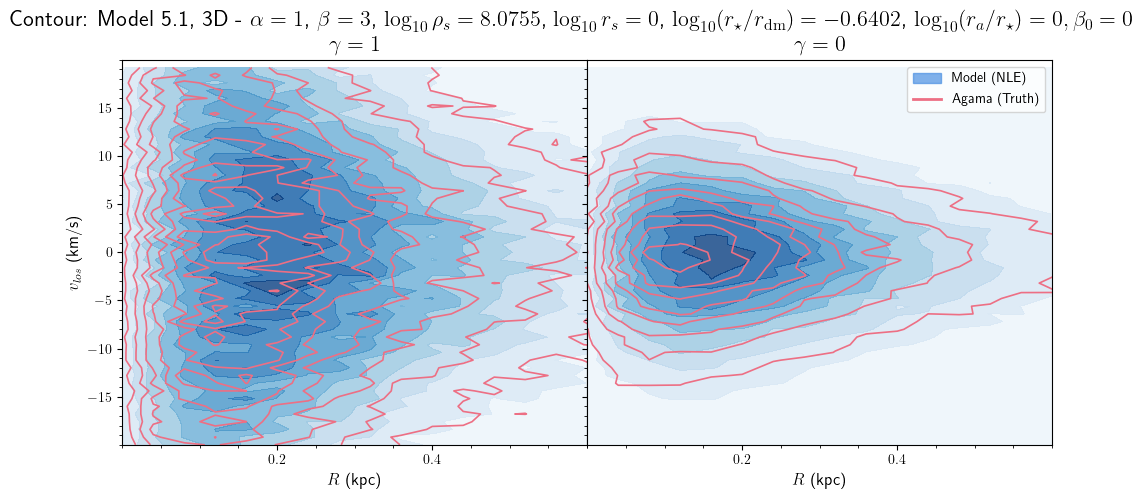

In [65]:
params = [1, 3, 8.0755, 0, -0.6402, 0, 0]
plot_figure(params)

In [34]:
a = load_csv("./model_7/3d/train_x.csv", "ndarray")

In [37]:
np.mean(a, axis=0)

array([-2.61327182e-02, -2.82236487e-02, -1.34338539e+02])